<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 10px;">
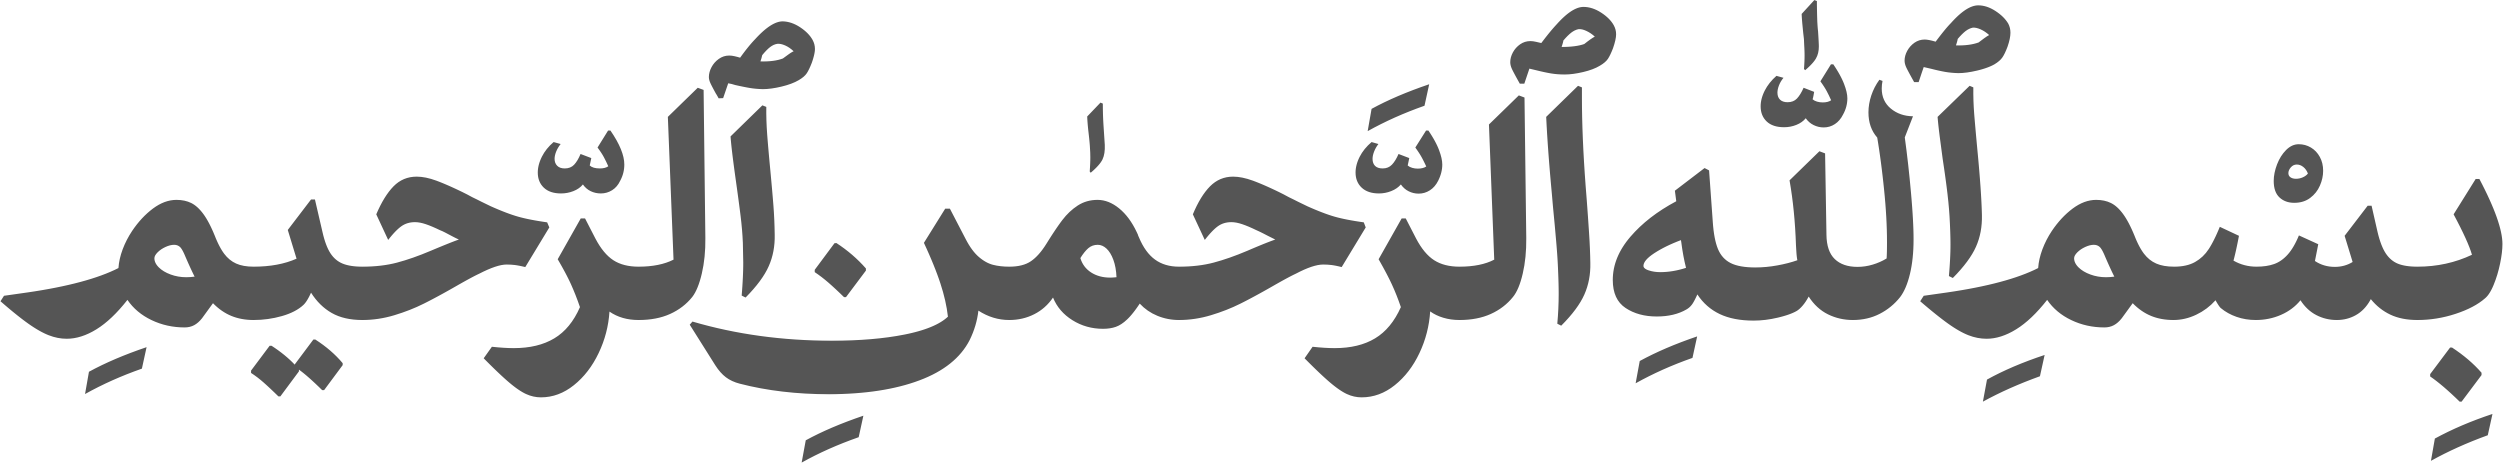
<div style="margin-top: 18px; display: flex; justify-content: center; align-items: center; gap: 30px;">
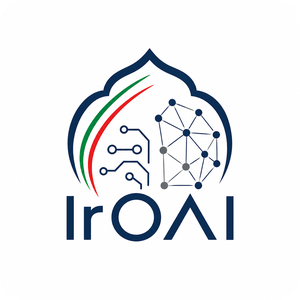
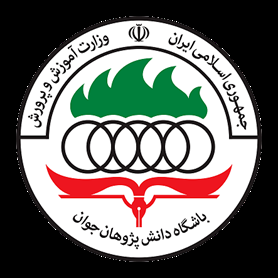
</div>
</div>
<h1 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">تمرین عملی المپیاد هوش مصنوعی — دوره دوم (۱۴۰۴-۱۴۰۵)</h1>
<h2 style="text-align: right; color: #3498db;">آشنایی با کاهش بُعد — پیاده‌سازی تحلیل مؤلفه‌های اصلی (PCA) از صفر</h2>
<p style="text-align: right;"><b>موضوع:</b>یادگیری بدون نظارت — کاهش بُعد</p>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. هدف، یادگیری و بررسی نتیجه کار خودتان است.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">مقدمه</h2>
<h3 style="text-align: right;">داده‌ها را به‌صورت نقطه‌هایی در یک فضای چندبعدی ببینیم</h3>
<p style="text-align: right;">فرض کنید هر داده یک بردار با <code dir="ltr">p</code> مؤلفه است، یعنی یک نقطه در فضای <code dir="ltr">p</code>-بعدی. اگر <code dir="ltr">n</code> داده داشته باشیم، آن‌ها را در یک ماتریس <code dir="ltr">X</code> با ابعاد <b dir="ltr">n × p</b> کنار هم می‌گذاریم: هر سطر یک داده و هر ستون یک ویژگی.</p>
<p style="text-align: right;">وقتی <code dir="ltr">p</code> بزرگ می‌شود، کار با داده سخت می‌شود: نمایش گرافیکی تقریبا ناممکن است، محاسبات سنگین‌تر می‌شوند، و مهم‌تر از همه، در داده‌های پرتعداد امّا پرمولفه اغلب بخش بزرگی از ستون‌ها یا ترکیب‌های آن‌ها اطلاعات کمی دارند. به این پدیده «نفرین ابعاد» (Curse of Dimensionality) می‌گویند.</p>
<h3 style="text-align: right;">ایده‌ی کاهش بُعد به کمک پروجکشن</h3>
<p style="text-align: right;">راه طبیعی این است که نقاط را روی یک فضای کم‌بُعدتر «تصویر» (Projection) کنیم؛ یعنی مختصات تازه‌ای برای هر نقطه پیدا کنیم که تعداد کمتری مؤلفه داشته باشد، اما ساختار اصلی داده را حفظ کند. در این تمرین به‌مرور یاد می‌گیریم چرا پروجکشن کار می‌کند، چطور با یک ضرب ماتریسی انجام می‌شود، و چطور PCA بهترین جهت‌های پروجکشن را پیدا می‌کند.</p>
<p style="text-align: right;">برای این‌که رفتار الگوریتم را دقیق ببینیم، در همه‌ی فازها از داده‌های ساخته‌شده (سینتتیک) با یک عدد ثابت برای تولید اعداد تصادفی (<code dir="ltr">SEED = 42</code>) استفاده می‌کنیم تا نتیجه‌ها برای همه قابل تکرار باشد.</p>
<ol style="text-align: right;"><li style="text-align: right;">فاز ۱: پروجکشن روی یک خط برای کاهش بُعد به یک</li><li style="text-align: right;">فاز ۲: چند پروجکشن هم‌زمان با ضرب ماتریسی</li><li style="text-align: right;">فاز ۳: چرا ماتریس تصادفی انتخاب خوبی نیست؛ معیار واریانس و قید اندازه</li><li style="text-align: right;">فاز ۴: ریاضیات PCA — ماتریس کوواریانس، بردارهای ویژه و مقادیر ویژه</li><li style="text-align: right;">فاز ۵: پیاده‌سازی کلاس PCA از صفر</li><li style="text-align: right;">فاز ۶: مقایسه با کلاس <code dir="ltr">PCA</code> در <code dir="ltr">scikit-learn</code></li><li style="text-align: right;">فاز ۷: اثر کاهش مؤلفه‌ها بر بایاس، واریانس، بیش‌برازش و کم‌برازش</li></ol>
</div>

In [1]:
# Setup - read-only cell; do not edit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import time
%matplotlib inline

SEED = 42


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۱ — پروجکشن روی یک خط: کاهش بُعد به یک</h2>
<p style="text-align: right;">ساده‌ترین حالت کاهش بُعد را در نظر بگیرید: نقاطی در صفحه (<code dir="ltr">p = 2</code>) را می‌خواهیم به یک عدد تبدیل کنیم (<code dir="ltr">p = 1</code>). یعنی هر نقطه را روی یک خطِ عبوری از مبدأ «تصویر» می‌کنیم و فقط مختصات آن را روی خط نگه می‌داریم.</p>
<p style="text-align: right;">اگر <code dir="ltr">w</code> بردار جهتِ واحدِ آن خط باشد، مختصات تصویر نقطه‌ی <code dir="ltr">x</code> روی خط، برابر ضرب داخلی (داخلی‌نما) آن دو است:</p>
$$
\mathbf{z}_i = \mathbf{x}_i^\top \mathbf{w} = \sum_{j=1}^{p} x_{ij} w_j
$$
<p style="text-align: right;">و خودِ نقطه‌ی تصویرشده روی خط (برای رسم) برابر است با:</p>
$$
\mathrm{proj}_{\mathbf{w}}(\mathbf{x}_i) = (\mathbf{x}_i^\top \mathbf{w})\, \mathbf{w}
$$
<p style="text-align: right;">در سلول بعدی یک ابر نقطه‌ی دوبعدی کشیده می‌شود که گستردگی آن در یک جهت بیشتر است. یک خط تصادفی انتخاب کرده‌ایم و همه‌ی نقاط را روی آن تصویر کرده‌ایم (خط‌های خاکستری، مسیر تصویر هر نقطه را نشان می‌دهند). توجه کنید هر نقطه بعد از پروجکشن فقط با یک عددِ حقیقی توصیف می‌شود.</p>
</div>

In [2]:
# Data for Phase 1 - a 2D elongated point cloud (read-only)
rng = np.random.default_rng(SEED)
n_2d = 250
X2 = rng.multivariate_normal(mean=[0.0, 0.0], cov=[[3.2, 1.1], [1.1, 0.9]], size=n_2d)
print("X2 shape:", X2.shape)


X2 shape: (250, 2)


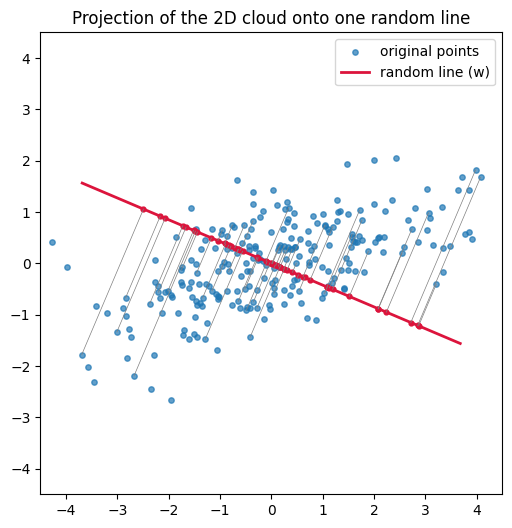

random direction w = [0.921, -0.391], ||w|| = 1.000
variance of the 1D projections: 2.057


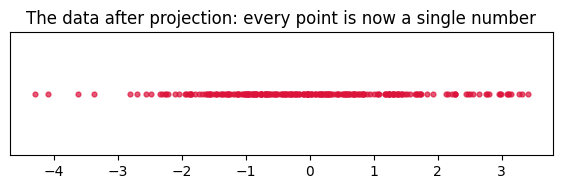

In [3]:
# Demo: projecting the 2D cloud onto one random line (read-only)
theta = rng.uniform(-np.pi / 2, np.pi / 2)
w0 = np.array([np.cos(theta), np.sin(theta)])
coords = X2 @ w0
proj_points = np.outer(coords, w0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X2[:, 0], X2[:, 1], s=15, alpha=0.7, label="original points")
t = np.linspace(-4, 4, 2)
ax.plot(t * w0[0], t * w0[1], color="crimson", lw=2, label="random line (w)")
for i in range(0, n_2d, 5):
    ax.plot([X2[i, 0], proj_points[i, 0]], [X2[i, 1], proj_points[i, 1]], color="gray", lw=0.5)
ax.scatter(proj_points[::5, 0], proj_points[::5, 1], color="crimson", s=12)
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect("equal")
ax.set_title("Projection of the 2D cloud onto one random line")
ax.legend()
plt.show()

print(f"random direction w = [{w0[0]:.3f}, {w0[1]:.3f}], ||w|| = {np.linalg.norm(w0):.3f}")
print(f"variance of the 1D projections: {coords.var():.3f}")

fig, ax = plt.subplots(figsize=(7, 1.6))
ax.scatter(coords, np.zeros_like(coords), s=12, alpha=0.7, color="crimson")
ax.set_yticks([])
ax.set_title("The data after projection: every point is now a single number")
plt.show()


z_use shape: (250,)
variance of this projection: 3.2200


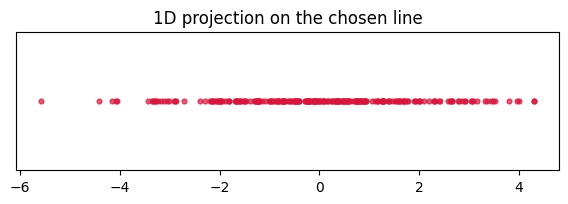

In [4]:
def project(X, w):
    # scalar projection of every row of X onto the direction w
    return X @ w

w_use = np.array([np.cos(0.6), np.sin(0.6)])
z_use = project(X2, w_use)
print("z_use shape:", z_use.shape)
print("variance of this projection: %.4f" % z_use.var())

plt.figure(figsize=(7, 1.8))
plt.scatter(z_use, np.zeros_like(z_use), s=12, alpha=0.7, color="crimson")
plt.title("1D projection on the chosen line")
plt.yticks([])
plt.show()


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">راهنمایی</h3>
<details style="text-align: right;"><summary style="text-align: right;">راه‌حل پیشنهادی برای پروجکشن</summary><p style="text-align: right;">برای هر سطر <code dir="ltr">X</code>، ضرب داخلی با <code dir="ltr">w</code> را محاسبه کنید. اگر <code dir="ltr">X</code> را به‌صورت ماتریس <b dir="ltr">n × p</b> و <code dir="ltr">w</code> را بردار <b dir="ltr">p</b> بگیرید، همین عملیات با یک ضرب ماتریس-بردارِ واحد انجام می‌شود: <code dir="ltr">X @ w</code>.</p><p style="text-align: right;">برای رسم، نقاط <code dir="ltr">z</code> را روی یک محور افقی پخش کنید: <code dir="ltr">plt.scatter(z, np.zeros_like(z))</code> و سپس <code dir="ltr">plt.yticks([])</code>.</p></details>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">بعد از نوشتن تابع، خروجی سلول را اجرا کنید و مقدار واریانس را با مقدار سلول نمایشی بالا مقایسه کنید.</p>
<p style="text-align: right; background-color: #fff3cd; color: #856404; padding: 8px; border-radius: 6px;">نکته: اگر بردار <code dir="ltr">w</code> واحد نباشد، طول تصویرها با اندازه‌ی <code dir="ltr">w</code> مقیاس می‌گیرد. این نکته در فاز ۳ خیلی مهم می‌شود!</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;"><li style="text-align: right;">در پروجکشن روی خط تصادفی، چه اطلاعاتی از داده از بین رفت؟</li><li style="text-align: right;">اگر بخواهیم «بهترین» خط را برای این ابر نقطه انتخاب کنیم، به نظر شما بهترین خط چه ویژگی‌ای دارد؟</li></ul>
<h3 style="text-align: right;">پاسخ پیشنهادی</h3>
<p style="text-align: right;">در پروجکشن روی یک خط، فقط مؤلفه‌ی هر نقطه در جهتِ آن خط حفظ می‌شود؛ فاصله‌ی نقاط در جهتِ عمود بر خط از بین می‌رود. مثلا اگر دو نقطه فقط در راستای عمود بر خط با هم تفاوت داشته باشند، بعد از تصویر شدن روی هم می‌افتند و قابل تشخیص نیستند.</p>
<p style="text-align: right;">بهترین خط، خطی است که داده‌ی تصویرشده روی آن بیشترین «پراکندگی» (واریانس) را داشته باشد؛ یعنی همان جهتی که ابر نقطه در آن کشیده‌تر است. در نمودار فاز ۳ دیدیم که بهترین جهت، واریانس را از حدود ۲ به حدود ۳.۴ می‌رساند.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۲ — چند پروجکشن هم‌زمان: ضرب ماتریسی</h2>
<p style="text-align: right;">کاهش بُعد معمولا به «یک» جهت محدود نیست؛ می‌خواهیم داده را از <code dir="ltr">p</code> بُعد به <code dir="ltr">k</code> بُعد ببریم (<code dir="ltr">k < p</code>). برای این کار به جای یک جهت، <code dir="ltr">k</code> جهت انتخاب می‌کنیم: <code dir="ltr">w_1, ..., w_k</code>، و مختصات تازه‌ی هر نقطه را ستون‌وار از ضرب داخلی آن با هر جهت می‌سازیم:</p>
$$
\mathbf{z}_i = \big(\mathbf{x}_i^\top \mathbf{w}_1,\; \mathbf{x}_i^\top \mathbf{w}_2,\; \dots,\; \mathbf{x}_i^\top \mathbf{w}_k\big)
$$
<p style="text-align: right;">اگر جهت‌ها را ستون‌های یک ماتریس <code dir="ltr">W</code> با ابعاد <b dir="ltr">p × k</b> بگذاریم، کل این محاسبه یک ضرب ماتریسی ساده می‌شود:</p>
$$
\underbrace{Z}_{n\times k} \;=\; \underbrace{X}_{n\times p}\;\underbrace{W}_{p\times k}
$$
<p style="text-align: right;">هر سطر <code dir="ltr">Z</code> همان مختصات «جدید» نقطه‌ی متناظر در فضای <code dir="ltr">k</code>-بعدی است. پس کاهش بُعد یعنی انتخاب یک ماتریس <code dir="ltr">W</code> و ضرب کردن داده در آن.</p>
<p style="text-align: right;">در سلول‌های بعدی داده‌ای سه‌بعدی می‌سازیم که نقاطش نزدیک یک «صفحه‌ی مایل» در فضا پخش شده‌اند (مثل یک پنکیکِ کج‌شده). ابتدا یک ماتریس تصادفی <code dir="ltr">W (3×2)</code> انتخاب می‌کنیم و داده را با آن به دو بُعد می‌بریم و نتیجه را می‌بینیم.</p>
</div>

X3 shape: (400, 3)


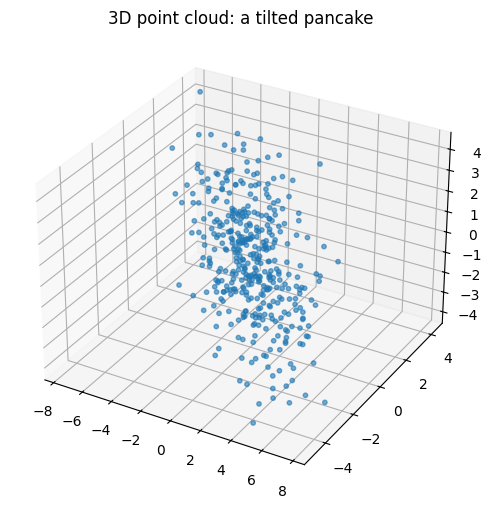

In [5]:
# Data for Phase 2 - a 3D 'pancake' point cloud: points near a tilted plane (read-only)
Z_lat3 = np.column_stack([rng.normal(0, 3.0, 400), rng.normal(0, 1.2, 400), rng.normal(0, 0.35, 400)])
R3, _ = np.linalg.qr(rng.normal(size=(3, 3)))   # a random rotation
X3 = Z_lat3 @ R3.T
print("X3 shape:", X3.shape)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=10, alpha=0.6)
ax.set_title("3D point cloud: a tilted pancake")
plt.show()


W_rand_demo shape: (3, 2) | Z_rand_demo shape: (400, 2)
variance along direction 1: 0.559
variance along direction 2: 6.415


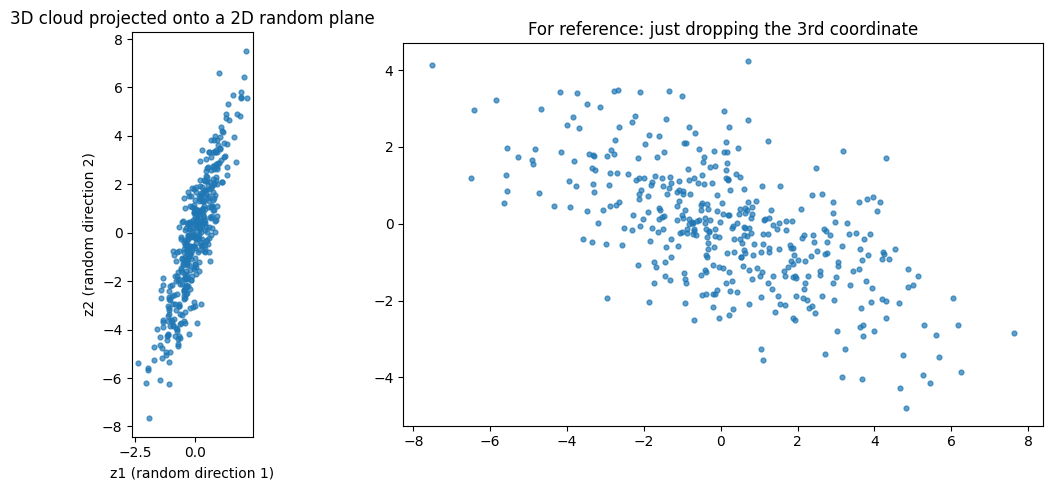

In [6]:
# Demo: projecting the 3D cloud onto 2 random directions with one matrix product (read-only)
W_rand_demo = rng.normal(size=(3, 2))
W_rand_demo = W_rand_demo / np.linalg.norm(W_rand_demo, axis=0, keepdims=True)
Z_rand_demo = X3 @ W_rand_demo
print("W_rand_demo shape:", W_rand_demo.shape, "| Z_rand_demo shape:", Z_rand_demo.shape)
print("variance along direction 1: %.3f" % Z_rand_demo[:, 0].var())
print("variance along direction 2: %.3f" % Z_rand_demo[:, 1].var())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(Z_rand_demo[:, 0], Z_rand_demo[:, 1], s=12, alpha=0.7)
ax.set_aspect("equal")
ax.set_xlabel("z1 (random direction 1)")
ax.set_ylabel("z2 (random direction 2)")
ax.set_title("3D cloud projected onto a 2D random plane")
ax = axes[1]
ax.scatter(X3[:, 0], X3[:, 1], s=12, alpha=0.7)
ax.set_aspect("equal")
ax.set_title("For reference: just dropping the 3rd coordinate")
plt.tight_layout()
plt.show()


W_rand shape: (3, 2) | Z_rand shape: (400, 2)


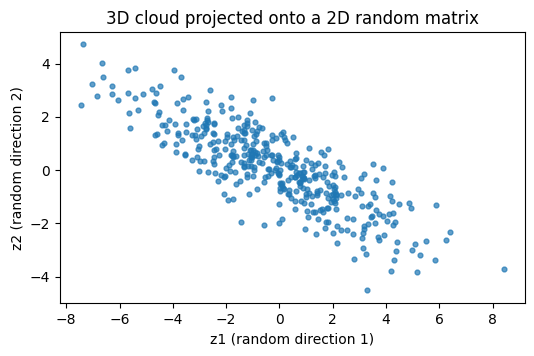

In [7]:
def project_matrix(X, W):
    # one matrix product computes the projections on all k directions at once
    return X @ W

W_rand = rng.normal(size=(3, 2))
W_rand = W_rand / np.linalg.norm(W_rand, axis=0, keepdims=True)
Z_rand = project_matrix(X3, W_rand)
print("W_rand shape:", W_rand.shape, "| Z_rand shape:", Z_rand.shape)

plt.figure(figsize=(6, 5))
plt.scatter(Z_rand[:, 0], Z_rand[:, 1], s=12, alpha=0.7)
plt.xlabel("z1 (random direction 1)")
plt.ylabel("z2 (random direction 2)")
plt.title("3D cloud projected onto a 2D random matrix")
plt.gca().set_aspect("equal")
plt.show()


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;"><li style="text-align: right;">در پروجکشن تصادفی بالا، آیا شکل «پنکیک» در نتیجه‌ی دوبعدی دیده می‌شود؟</li><li style="text-align: right;">اگر بخواهیم شکل پنکیک (یعنی صفحه‌ای که نقاط روی آن پخش شده‌اند) در پروجکشن دوبعدی حفظ شود، جهت‌ها باید چه رابطه‌ای با آن صفحه داشته باشند؟</li></ul>
<h3 style="text-align: right;">پاسخ پیشنهادی</h3>
<p style="text-align: right;">در پروجکشن با ماتریس تصادفی معمولا نه؛ چون جهت‌های تصادفی هم‌راستا با صفحه‌ی پنکیک نیستند، شکل پنکیک له می‌شود (در خروجی، یکی از جهت‌های تصادفی فقط ۰.۵۶ واحد واریانس نگه داشت).</p>
<p style="text-align: right;">برای حفظ شکل، دو جهت پروجکشن باید «داخل» صفحه‌ی پنکیک باشند. در آن صورت دو بُعدی که پنکیک در آن‌ها کشیده است دیده می‌شود و فقط بُعدِ سوم (ضخامت کمِ پنکیک) از بین می‌رود که تقریبا اطلاعاتی ندارد.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۳ — ماتریس تصادفی بهترین انتخاب نیست</h2>
<p style="text-align: right;">تا اینجا <code dir="ltr">W</code> را تصادفی گرفتیم؛ اما این یک انتخاب شانسی است. گاهی ساختار داده را حفظ می‌کند و گاهی آن را کاملا له می‌کند. خبر خوب این است که <code dir="ltr">W</code> را خودمان انتخاب می‌کنیم؛ پس می‌توانیم آن را بهینه کنیم. اول باید یک «معیار خوبی» برای یک جهت پروجکشن تعریف کنیم.</p>
<h2 style="text-align: right; color: #3498db;">معیار خوبی: واریانس — استعاره‌ی عکس گرفتن از یک جمعیت</h2>
<p style="text-align: right;">فرض کنید از یک گروه از مردم می‌خواهید عکس بگیرید. اگر از «روبرو» عکس بگیرید، افراد در عرض قاب پراکنده‌اند و جای هر نفر در عکس دیده می‌شود؛ یعنی تفاوت موقعیت‌ها حفظ می‌شود. اما اگر از «کنار» (یعنی عمود بر صفِ آن‌ها) عکس بگیرید، همه‌ی افراد تقریبا روی یک نقطه می‌افتند و دیگر نمی‌شود تشخیص داد چه کسی کجاست؛ اطلاعاتِ موقعیت از بین رفته است. عکس شما در هر دو حالت، یک «پروجکشن» از صحنه است؛ فقط جهت دوربین فرق کرده است.</p>
<p style="text-align: right;">در داده هم همین‌طور: پروجکشن یعنی «تصویر کردن» نقاط روی یک خط یا صفحه، و جهتِ تصویر تعیین می‌کند چه مقدار از پراکندگی نقاط دیده شود. جهت خوب، جهتی است که داده‌های تصویرشده روی آن «واریانس» (Variance) زیادی داشته باشند؛ یعنی نقاط بعد از تصویر شدن از هم باز بمانند و روی هم نیفتند، چون اگر روی هم بیفتند نمونه‌های متفاوت قابل تشخیص نیستند و اطلاعات از بین رفته است. پس هدف PCA این است که بهترین «زاویه‌های دوربین» یعنی جهت‌هایی که واریانس پروجکشن را بیشینه می‌کنند را پیدا کند.</p>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">توجه کنید این استعاره فقط یک «تصویر شهودی» است و خودِ تعریف ریاضی نیست. پیامی که می‌خواهد برساند فقط حفظ اطلاعات است: جهت خوب، جهتی است که تمایز بین نمونه‌ها و در نتیجه اطلاعات را حفظ می‌کند؛ نه این‌که آن جهت به‌تنهایی «مهم‌تر» یا «باارزش‌تر» است.</p>
<p style="text-align: right;">در سلول نمایشی بعدی، برای داده‌ی دوبعدی خودمان، واریانس پروجکشن را برای همه‌ی زاویه‌ها محاسبه کرده و بهترین زاویه را با چند جهت تصادفی مقایسه می‌کنیم.</p>
</div>

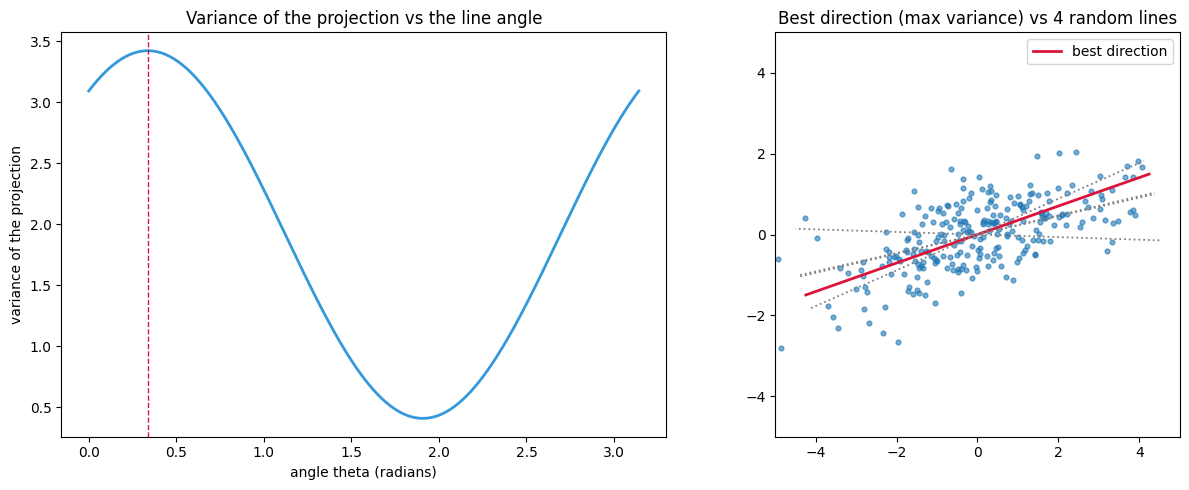

variance along the best direction: 3.424


In [8]:
# Demo: variance of the projection as a function of the line angle (read-only)
angs = np.linspace(0, np.pi, 400)
vars_ = np.array([(X2 @ np.array([np.cos(t), np.sin(t)])).var() for t in angs])
best_angle = angs[np.argmax(vars_)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(angs, vars_, lw=2, color="#3498db")
ax.axvline(best_angle, color="crimson", ls="--", lw=1)
ax.set_xlabel("angle theta (radians)")
ax.set_ylabel("variance of the projection")
ax.set_title("Variance of the projection vs the line angle")

ax = axes[1]
ax.scatter(X2[:, 0], X2[:, 1], s=12, alpha=0.6)
w_best = np.array([np.cos(best_angle), np.sin(best_angle)])
t_line = np.linspace(-4.5, 4.5, 2)
ax.plot(t_line * w_best[0], t_line * w_best[1], color="crimson", lw=2, label="best direction")
for _ in range(4):
    th_r = rng.uniform(0, np.pi)
    w_r = np.array([np.cos(th_r), np.sin(th_r)])
    ax.plot(t_line * w_r[0], t_line * w_r[1], color="gray", ls=":", lw=1.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")
ax.set_title("Best direction (max variance) vs 4 random lines")
ax.legend()
plt.tight_layout()
plt.show()
print("variance along the best direction: %.3f" % vars_.max())


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">قید اندازه‌ی جهت‌ها: چرا باید <code dir="ltr">||w|| = 1</code>؟</h2>
<p style="text-align: right;">یک دام ظریف وجود دارد. بردارهای <code dir="ltr">w</code> و <code dir="ltr">2w</code> «همان خط» را نشان می‌دهند ولی اگر محاسبه کنیم، واریانس پروجکشن روی <code dir="ltr">2w</code> چهار برابر واریانس روی <code dir="ltr">w</code> است! در حالت کلی:</p>
$$
\operatorname{Var}(X\mathbf{w}) = \mathbf{w}^\top \Sigma \mathbf{w},\qquad \Sigma = \frac{1}{n-1} X_c^\top X_c
$$
<p style="text-align: right;">که در آن <code dir="ltr">Σ</code> «ماتریس کوواریانس» داده است. با بزرگ‌کردن اندازه‌ی <code dir="ltr">w</code> به‌اندازه‌ی <code dir="ltr">c</code> داریم:</p>
$$
\operatorname{Var}(X(c\mathbf{w})) = c^2\, \mathbf{w}^\top \Sigma \mathbf{w}
$$
<p style="text-align: right;">پس با بزرگ‌کردن اندازه‌ی <code dir="ltr">w</code> می‌توان واریانس را خودسرانه هر قدر که بخواهیم بزرگ کرد و مقایسه‌ی جهت‌ها بی‌معنی می‌شود. برای اینکه مقایسه منصفانه باشد، همه‌ی جهت‌ها را به یک اندازه‌ در می‌آوریم؛ قرارداد رایج این است که <code dir="ltr">||w|| = 1</code> باشد (یا هر عدد ثابت دیگری). با این قید، مختصات پروجکشن همان «فاصله‌ی علامت‌دار» نقطه روی خط می‌شود.</p>
<p style="text-align: right; background-color: #fff3cd; color: #856404; padding: 8px; border-radius: 6px;">قید <code dir="ltr">||w|| = 1</code> فقط برای مقایسه‌ی منصفانه است؛ خودِ خط به اندازه‌ی <code dir="ltr">w</code> وابسته نیست.</p>
</div>

In [9]:
w_small = np.array([1.0, 0.0])
w_big = 4.0 * w_small
print("||w_small||: %.3f | ||w_big||: %.3f" % (np.linalg.norm(w_small), np.linalg.norm(w_big)))
as_is = project(X2, w_small).var()
scaled = project(X2, w_big).var()
print("variance along w_small: %.4f" % as_is)
print("variance along 4*w_small: %.4f" % scaled)
print("ratio: %.3f  (expect 4^2 = 16)" % (scaled / as_is))
w_norm = w_big / np.linalg.norm(w_big)
print("variance along normalized w_big: %.4f (must equal the first variance)"
      % project(X2, w_norm).var())


||w_small||: 1.000 | ||w_big||: 4.000
variance along w_small: 3.0934
variance along 4*w_small: 49.4940
ratio: 16.000  (expect 4^2 = 16)
variance along normalized w_big: 3.0934 (must equal the first variance)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;"><li style="text-align: right;">چرا «بزرگ‌کردن» <code dir="ltr">w</code> برای افزایش واریانس را می‌توان یک تقلب در نظر گرفت؟</li><li style="text-align: right;">با این قید، مسئله‌ی بهینه‌سازی چه شکلی پیدا می‌کند؟ (بیشینه‌سازی یک تابع با یک قید)</li></ul>
<h3 style="text-align: right;">پاسخ پیشنهادی</h3>
<p style="text-align: right;">چون <code dir="ltr">w</code> و <code dir="ltr">c·w</code> «همان خط» را نشان می‌دهند و خطِ انتخاب‌شده اصلا عوض نمی‌شود؛ فقط اعدادِ مختصات بزرگ‌تر می‌شوند. پس افزایش واریانس با بزرگ‌کردن اندازه، هیچ اطلاعات جدیدی اضافه نمی‌کند و مقایسه‌ی منصفانه‌ی جهت‌ها را بی‌معنی می‌کند.</p>
<p style="text-align: right;">با قید <code dir="ltr">||w|| = 1</code> مسئله یک بهینه‌سازی مقید می‌شود: بیشینه‌کردن <code dir="ltr">w^T Σ w</code> به شرط <code dir="ltr">w^T w = 1</code>، که جوابش بردار ویژه‌ی کوواریانس با بزرگ‌ترین مقدار ویژه است (فاز ۴).</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۴ — ریاضیات PCA: ماتریس کوواریانس، بردارهای ویژه و مقادیر ویژه</h2>
<p style="text-align: right;">حالا می‌خواهیم جهتِ واحدِ <code dir="ltr">w</code> را پیدا کنیم که <code dir="ltr">w^T Σ w</code> را بیشینه می‌کند. این یک بهینه‌سازی مقید است:</p>
$$
\max_{\mathbf{w}} \;\mathbf{w}^\top \Sigma \mathbf{w}\qquad \text{subject to}\qquad \mathbf{w}^\top \mathbf{w} = 1
$$
<p style="text-align: right;">با روش ضریب لاگرانژ می‌توان نشان داد که جواب، یکی از «بردارهای ویژه» (Eigenvectors) ماتریس کوواریانس است: بردار ویژه‌ای که به «بزرگ‌ترین مقدار ویژه» (Eigenvalue) مربوط است. بردار ویژه و مقدار ویژه، جفت‌هایی هستند که رابطه‌ی زیر را برقرار می‌کنند:</p>
$$
\Sigma \mathbf{v} = \lambda \mathbf{v}
$$
<p style="text-align: right;">ماتریس کوواریانس <code dir="ltr">Σ</code> متقارن است؛ پس همه‌ی <code dir="ltr">p</code> بردار ویژه‌ی آن، یک پایه‌ی متعامد می‌سازند و مقدارهای ویژه‌اش نامنفی‌اند. اگر آن‌ها را نزولی مرتب کنیم:</p>
$$
\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p \ge 0
$$
<p style="text-align: right;">آنگاه:</p>
<ul style="text-align: right;"><li style="text-align: right;">جهت اول PCA (<code dir="ltr">PC1</code>) = بردار ویژه‌ی متناظر با <code dir="ltr">λ₁</code>، و واریانس پروجکشن روی آن دقیقا برابر <code dir="ltr">λ₁</code> است.</li><li style="text-align: right;">جهت دوم PCA = بردار ویژه‌ی متناظر با <code dir="ltr">λ₂</code> (عمود بر جهت اول) و به همین ترتیب برای بقیه.</li><li style="text-align: right;">کاهش بُعد با PCA یعنی نگه‌داشتن <code dir="ltr">k</code> بردار ویژه‌ی اول و کنار گذاشتن بقیه.</li></ul>
<p style="text-align: right;">مقدار ویژه‌ها می‌گویند هر جهت «چقدر واریانس» را حمل می‌کند. نسبت واریانس توضیح‌داده‌شده توسط <code dir="ltr">k</code> مؤلفه‌ی اول برابر است با:</p>
$$
\frac{\lambda_1+\dots+\lambda_k}{\lambda_1+\dots+\lambda_p}
$$
<p style="text-align: right;">رابطه‌ی مهم دیگر: اگر <code dir="ltr">X_c</code> را با تجزیه‌ی مقادیر تکین (SVD) تجزیه کنیم، <code dir="ltr">X_c = U S V^T</code>، ستون‌های <code dir="ltr">V</code> دقیقا همان بردارهای ویژه‌اند و <code dir="ltr">λ_i = s_i² / (n-1)</code>. به همین دلیل کتابخانه‌ها معمولا PCA را با SVD پیاده‌سازی می‌کنند.</p>
<p style="text-align: right;">در سلول‌های زیر، همین محاسبات را روی داده‌ی دوبعدی و سه‌بعدی خودمان انجام می‌دهیم و جهت‌های PCA را روی داده رسم می‌کنیم.</p>
</div>

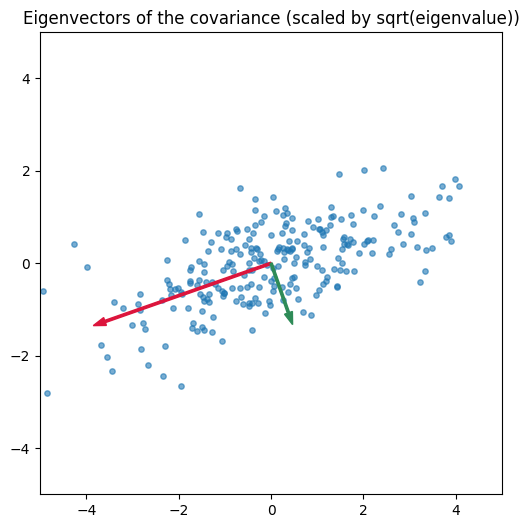

eigenvalues (variance of the PCs): [3.4373 0.4087]
explained variance ratio: [0.8937 0.1063]


In [10]:
# Demo: the eigenvectors of the covariance matrix on the 2D cloud (read-only)
X2c = X2 - X2.mean(axis=0)
cov2 = np.cov(X2c, rowvar=False)
evals2, evecs2 = np.linalg.eigh(cov2)
order = np.argsort(evals2)[::-1]
evals2, evecs2 = evals2[order], evecs2[:, order]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X2[:, 0], X2[:, 1], s=15, alpha=0.6)
for i in range(2):
    v = evecs2[:, i] * np.sqrt(evals2[i]) * 2.2
    ax.arrow(0, 0, v[0], v[1], color=["crimson", "seagreen"][i], width=0.05,
             head_width=0.18, length_includes_head=True)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")
ax.set_title("Eigenvectors of the covariance (scaled by sqrt(eigenvalue))")
plt.show()
print("eigenvalues (variance of the PCs):", np.round(evals2, 4))
print("explained variance ratio:", np.round(evals2 / evals2.sum(), 4))


In [11]:
def eigen_pca(X, k):
    Xc = X - X.mean(axis=0)
    cov = np.cov(Xc, rowvar=False)          # p x p covariance matrix
    eigvals, eigvecs = np.linalg.eigh(cov)  # ascending order
    order = np.argsort(eigvals)[::-1]       # descending order
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    return eigvecs[:, :k], eigvals[:k]

vecs2, vals2 = eigen_pca(X2, 2)
print("eigenvalues:", np.round(vals2, 4))
print("explained variance ratio:", np.round(vals2 / vals2.sum(), 4))
print("first eigenvector (PC1):", np.round(vecs2[:, 0], 4))


eigenvalues: [3.4373 0.4087]
explained variance ratio: [0.8937 0.1063]
first eigenvector (PC1): [-0.9437 -0.3308]


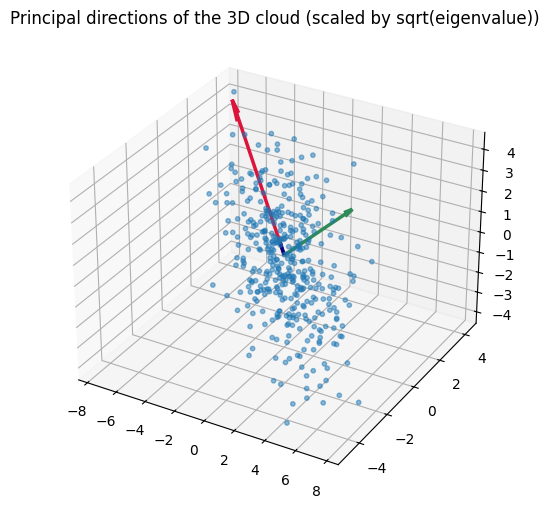

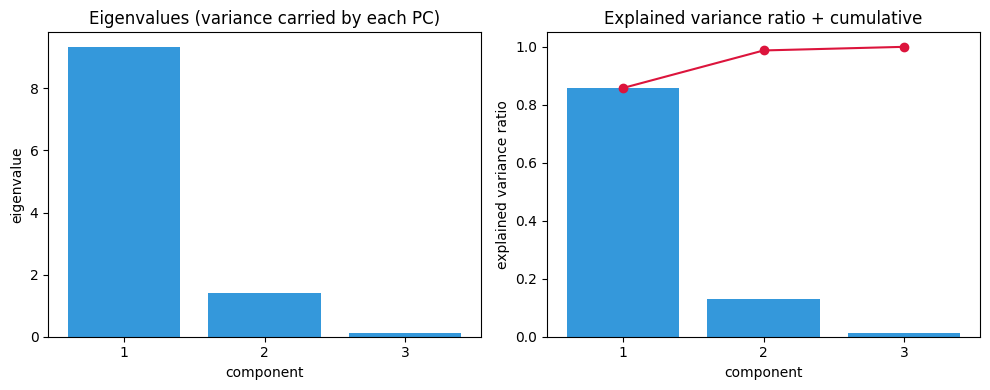

explained variance ratios of the 3 components: [0.8581 0.1295 0.0125]
ratio captured by the first 2 components: 0.9875


In [12]:
# Demo: the 3 principal directions of the 3D cloud (read-only)
X3c = X3 - X3.mean(axis=0)
cov3 = np.cov(X3c, rowvar=False)
evals3, evecs3 = np.linalg.eigh(cov3)
order = np.argsort(evals3)[::-1]
evals3, evecs3 = evals3[order], evecs3[:, order]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=10, alpha=0.5)
for i, col in enumerate(["crimson", "seagreen", "navy"]):
    v = evecs3[:, i] * np.sqrt(evals3[i]) * 3.0
    ax.quiver(0, 0, 0, v[0], v[1], v[2], color=col, linewidth=2.5, arrow_length_ratio=0.12)
ax.set_title("Principal directions of the 3D cloud (scaled by sqrt(eigenvalue))")
plt.show()

ratios3 = evals3 / evals3.sum()
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, 4), evals3, color="#3498db")
plt.xticks([1, 2, 3])
plt.xlabel("component")
plt.ylabel("eigenvalue")
plt.title("Eigenvalues (variance carried by each PC)")
plt.subplot(1, 2, 2)
plt.bar(range(1, 4), ratios3, color="#3498db")
plt.plot(range(1, 4), np.cumsum(ratios3), "o-", color="crimson")
plt.xticks([1, 2, 3])
plt.xlabel("component")
plt.ylabel("explained variance ratio")
plt.title("Explained variance ratio + cumulative")
plt.tight_layout()
plt.show()
print("explained variance ratios of the 3 components:", np.round(ratios3, 4))
print("ratio captured by the first 2 components:", round(ratios3[:2].sum(), 4))


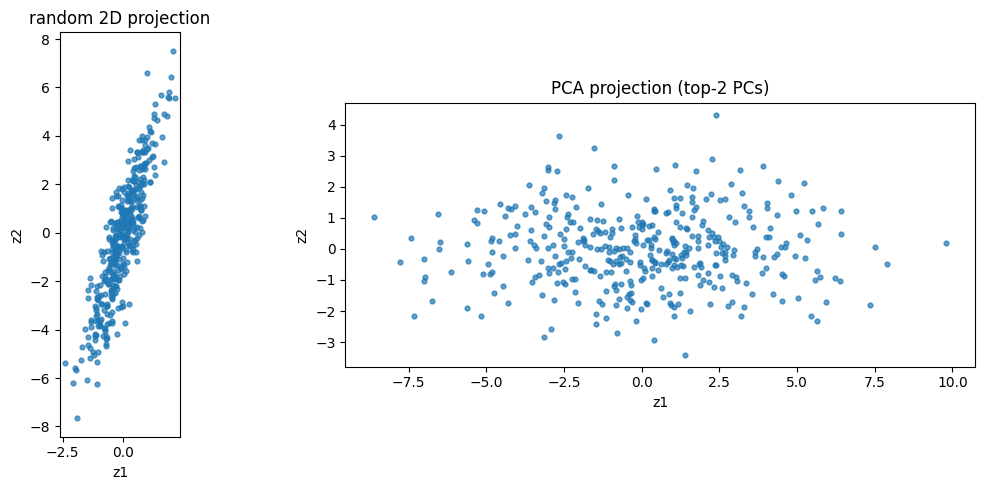

total variance kept by the random projection: 6.973
total variance kept by the PCA projection : 10.716


In [13]:
# Demo: random projection vs PCA projection of the same 3D cloud (read-only)
Z_pca_demo = X3c @ evecs3[:, :2]     # project on the top-2 principal directions
Z_rnd2_demo = X3 @ W_rand_demo       # the random directions from Phase 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (Z, title) in zip(axes, [(Z_rnd2_demo, "random 2D projection"),
                                 (Z_pca_demo, "PCA projection (top-2 PCs)")]):
    ax.scatter(Z[:, 0], Z[:, 1], s=12, alpha=0.7)
    ax.set_aspect("equal")
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_title(title)
plt.tight_layout()
plt.show()
print("total variance kept by the random projection: %.3f"
      % (Z_rnd2_demo.var(axis=0).sum()))
print("total variance kept by the PCA projection : %.3f"
      % (Z_pca_demo.var(axis=0).sum()))


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;"><li style="text-align: right;">چرا در نمودار «نسبت واریانس توضیح‌داده‌شده»، مؤلفه‌ی سوم تقریبا هیچ واریانسی ندارد؟ این با شکل پنکیک چه رابطه‌ای دارد؟</li><li style="text-align: right;">اگر داده را فقط با دو مؤلفه‌ی اول بازسازی کنیم، فکر می‌کنید چقدر خطا خواهیم داشت؟</li></ul>
<h3 style="text-align: right;">پاسخ پیشنهادی</h3>
<p style="text-align: right;">چون داده‌ی ما «پنکیکی» است: در جهت سوم (عمود بر صفحه‌ی پنکیک) ضخامت و در نتیجه تغییرات داده خیلی کم است (نسبت واریانس ≈ 0.012). پس مؤلفه‌ی سوم تقریبا هیچ اطلاعاتی حمل نمی‌کند.</p>
<p style="text-align: right;">با دو مؤلفه‌ی اول حدود 98.75٪ واریانس حفظ می‌شود؛ بنابراین خطای بازسازی بسیار کوچک است — در خروجی سلول‌ها، خطای بازسازی روی داده‌ی تست حدود 0.045 دیده می‌شود.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۵ — کلاس PCA از صفر</h2>
<p style="text-align: right;">حالا همه‌ی قطعات را کنار هم می‌گذاریم. یک کلاس PCA با همین رابط کاربردی کلاس <code dir="ltr">PCA</code> در <code dir="ltr">scikit-learn</code> می‌سازیم:</p>
<ul style="text-align: right;"><li style="text-align: right;"><code dir="ltr">fit(X)</code>: میانگین هر ستون را ذخیره می‌کند، ماتریس کوواریانس داده‌ی مرکزی‌شده را می‌سازد، تجزیه‌ی ویژه انجام می‌دهد و <code dir="ltr">k</code> بردار ویژه‌ی اول را به‌عنوان <code dir="ltr">components_</code> نگه می‌دارد (هر سطر <code dir="ltr">components_</code> یک جهت PCA است).</li><li style="text-align: right;"><code dir="ltr">transform(X)</code>: داده را با <code dir="ltr">(X - mean_) @ components_.T</code> به فضای <code dir="ltr">k</code>-بعدی می‌برد.</li><li style="text-align: right;"><code dir="ltr">inverse_transform(Z)</code>: از مختصات کم‌بعد به فضای اصلی برمی‌گردد: <code dir="ltr">Z @ components_ + mean_</code>. به این ترتیب می‌توان «خطای بازسازی» را اندازه گرفت.</li><li style="text-align: right;"><code dir="ltr">explained_variance_ratio_</code>: نسبت واریانس توضیح‌داده‌شده توسط هر مؤلفه.</li></ul>
<p style="text-align: right;">یک نکته‌ی مهم در انتخاب <code dir="ltr">k</code>: با رسم «خطای بازسازی» (فاصله‌ی داده‌ی اصلی تا بازسازی‌شده) بر حسب <code dir="ltr">k</code>، معمولا یک «آرنج» (Elbow) می‌بینیم؛ بعد از آن، اضافه‌کردن مؤلفه‌ی جدید خطا را به‌طور چشمگیر کم نمی‌کند. قانون متداول دیگر این است که به اندازه‌ی کافی مؤلفه نگه داریم تا مثلا ۹۵٪ واریانس توضیح داده شود.</p>
</div>

In [14]:
class PCAManual:
    """PCA implemented from scratch with numpy (eigendecomposition of the covariance)."""
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        n, p = X.shape
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        cov = np.cov(Xc, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(cov)
        order = np.argsort(eigvals)[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        k = p if self.n_components is None else self.n_components
        self.components_ = eigvecs[:, :k].T        # shape (k, p)
        self.explained_variance_ = eigvals[:k]
        self.explained_variance_ratio_ = eigvals[:k] / eigvals.sum()
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T   # shape (n, k)

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_       # back to the original space

    def fit_transform(self, X):
        return self.fit(X).transform(X)


explained variance ratio: [0.8581 0.1295]
sum of the first 2 ratios: 0.9875
reconstruction MSE (k=2): 0.04517


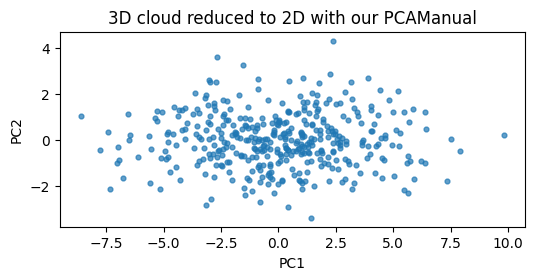

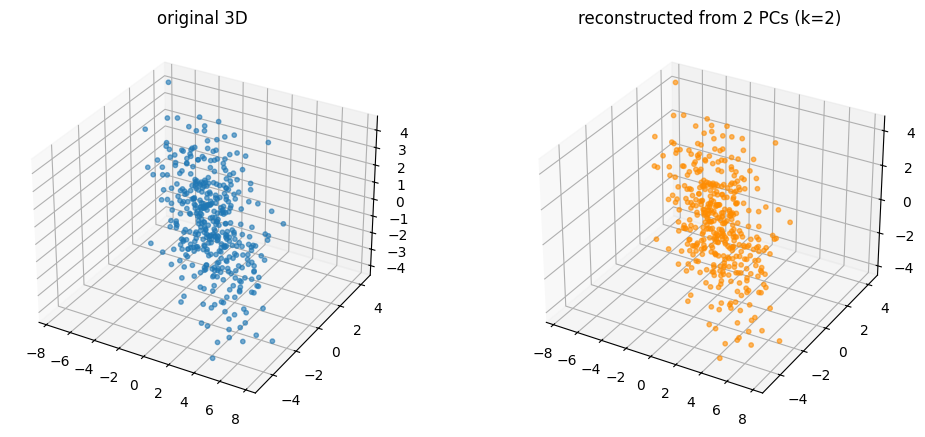

In [15]:
pca_m = PCAManual(n_components=2)
Z3 = pca_m.fit_transform(X3)
print("explained variance ratio:", np.round(pca_m.explained_variance_ratio_, 4))
print("sum of the first 2 ratios: %.4f" % pca_m.explained_variance_ratio_.sum())

X3_recon = pca_m.inverse_transform(Z3)
mse_manual = ((X3 - X3_recon) ** 2).mean()
print("reconstruction MSE (k=2): %.5f" % mse_manual)

plt.figure(figsize=(6, 5))
plt.scatter(Z3[:, 0], Z3[:, 1], s=12, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("3D cloud reduced to 2D with our PCAManual")
plt.gca().set_aspect("equal")
plt.show()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=10, alpha=0.6)
ax1.set_title("original 3D")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X3_recon[:, 0], X3_recon[:, 1], X3_recon[:, 2], s=10, alpha=0.6, color="darkorange")
ax2.set_title("reconstructed from 2 PCs (k=2)")
plt.show()


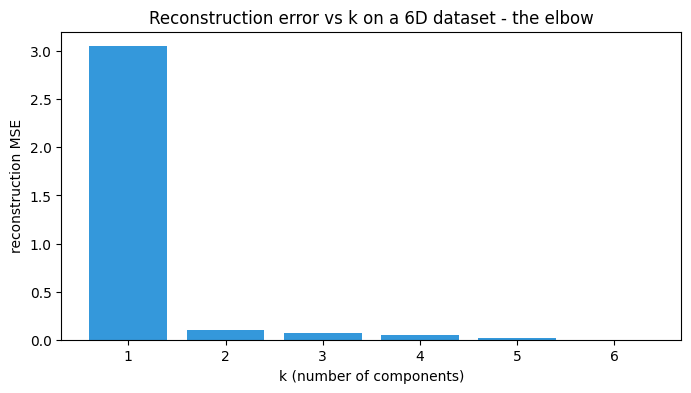

k=1: reconstruction MSE 3.0487
k=2: reconstruction MSE 0.1013
k=3: reconstruction MSE 0.0729
k=4: reconstruction MSE 0.0464
k=5: reconstruction MSE 0.0228
k=6: reconstruction MSE 0.0000


In [16]:
# Demo: reconstruction error vs the number of components (the elbow) (read-only)
rng5 = np.random.default_rng(11)
n6, p6 = 600, 6
lat6 = rng5.normal(size=(n6, 2)) @ np.diag([3.0, 1.5])
A6 = rng5.normal(size=(p6, 2))
X6 = lat6 @ A6.T + 0.4 * rng5.normal(size=(n6, p6))

errs = []
for k in range(1, p6 + 1):
    pca_k = PCA(n_components=k).fit(X6)
    rec = pca_k.inverse_transform(pca_k.transform(X6))
    errs.append(((X6 - rec) ** 2).mean())

plt.figure(figsize=(8, 4))
plt.bar(range(1, p6 + 1), errs, color="#3498db")
plt.xticks(range(1, p6 + 1))
plt.xlabel("k (number of components)")
plt.ylabel("reconstruction MSE")
plt.title("Reconstruction error vs k on a 6D dataset - the elbow")
plt.show()
for k, e in enumerate(errs, start=1):
    print(f"k={k}: reconstruction MSE {e:.4f}")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;"><li style="text-align: right;">در داده‌ی ۶ بعدی بالا، «آرنج» کجاست؟ با <code dir="ltr">k = 2</code> چند درصد واریانس توضیح داده می‌شود؟</li><li style="text-align: right;">اگر <code dir="ltr">k</code> را خیلی کوچک یا خیلی بزرگ بگیریم، به ترتیب چه اتفاقی برای خطای بازسازی می‌افتد؟</li></ul>
<h3 style="text-align: right;">پاسخ پیشنهادی</h3>
<p style="text-align: right;">آرنج حدود <code dir="ltr">k = 2</code> است: خطای بازسازی از 3.05 در <code dir="ltr">k = 1</code> به 0.10 در <code dir="ltr">k = 2</code> می‌افتد و بعد از آن تقریبا صاف می‌شود. چون داده عمدا از یک ساختار دوبعدی ساخته شده، دو مؤلفه‌ی اول حدود 99.4٪ واریانس را توضیح می‌دهند.</p>
<p style="text-align: right;">اگر <code dir="ltr">k</code> خیلی کوچک باشد، یکی از جهت‌های اصلی داده حذف می‌شود و خطای بازسازی بزرگ است؛ اگر خیلی بزرگ باشد، مؤلفه‌های نویزی اضافه می‌شوند که خطا را فقط اندکی کم می‌کنند (و در مسائل یادگیری، خطر بیش‌برازش را بالا می‌برند).</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۶ — مقایسه با PCA در scikit-learn</h2>
<p style="text-align: right;">کلاس <code dir="ltr">sklearn.decomposition.PCA</code> دقیقا همین کار را انجام می‌دهد با این تفاوت‌ها: به‌جای تجزیه‌ی ویژه‌ی ماتریس کوواریانس، معمولا از SVD استفاده می‌کند (از نظر عددی پایدارتر است) و از روال‌های بهینه‌شده‌ی خطی‌کتابخانه‌ای بهره می‌برد. یک تفاوت ظاهری هم این است که <code dir="ltr">components_</code> ممکن است با «علامت» مخالف خروجی ما باشد؛ چون اگر <code dir="ltr">v</code> بردار ویژه باشد، <code dir="ltr">-v</code> هم بردار ویژه است و هر دو همان خط را نشان می‌دهند.</p>
<p style="text-align: right;">در سلول وظیفه‌ی زیر، کلاس خودمان و <code dir="ltr">sklearn</code> را روی داده‌ی سه‌بعدی <code dir="ltr">X3</code> با <code dir="ltr">k = 2</code> مقایسه می‌کنیم: مؤلفه‌ها (با قدر مطلق، به‌خاطر علامت)، نسبت واریانس توضیح‌داده‌شده، خطای بازسازی، و در پایان زمان <code dir="ltr">fit</code> روی یک داده‌ی بزرگ‌تر را می‌سنجیم.</p>
</div>

In [17]:
pca_sk = PCA(n_components=2).fit(X3)
print("sklearn explained_variance_ratio_:", np.round(pca_sk.explained_variance_ratio_, 6))
print("manual   explained_variance_ratio_:", np.round(pca_m.explained_variance_ratio_, 6))
print("max |abs(components_sk) - abs(components_manual)|: %.6f"
      % np.abs(np.abs(pca_sk.components_) - np.abs(pca_m.components_)).max())

X3_recon_sk = pca_sk.inverse_transform(pca_sk.transform(X3))
print("reconstruction MSE sklearn: %.6f" % ((X3 - X3_recon_sk) ** 2).mean())
print("reconstruction MSE manual  : %.6f" % mse_manual)

rng_t = np.random.default_rng(0)
X_big = rng_t.normal(size=(8000, 30))
t0 = time.perf_counter()
PCA(n_components=5).fit(X_big)
t_sk = time.perf_counter() - t0
t0 = time.perf_counter()
PCAManual(n_components=5).fit(X_big)
t_man = time.perf_counter() - t0
print(f"sklearn fit time on 8000x30 : {t_sk * 1000:.2f} ms")
print(f"manual  fit time on 8000x30 : {t_man * 1000:.2f} ms")


sklearn explained_variance_ratio_: [0.858059 0.129454]
manual   explained_variance_ratio_: [0.858059 0.129454]
max |abs(components_sk) - abs(components_manual)|: 0.000000
reconstruction MSE sklearn: 0.045169
reconstruction MSE manual  : 0.045169
sklearn fit time on 8000x30 : 2.86 ms
manual  fit time on 8000x30 : 5.48 ms


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;"><li style="text-align: right;">آیا نتایج دو پیاده‌سازی از نظر عددی هم‌خوانی داشتند؟ تفاوت علامت در مؤلفه‌ها چه معنایی دارد؟</li><li style="text-align: right;">به نظر شما کدام پیاده‌سازی برای داده‌های خیلی بزرگ (مثلا ۱۰۰ هزار نمونه) مناسب‌تر است و چرا؟</li></ul>
<h3 style="text-align: right;">پاسخ پیشنهادی</h3>
<p style="text-align: right;">بله، کاملا هم‌خوانی داشتند: نسبت واریانس توضیح‌داده‌شده و خطای بازسازی دو پیاده‌سازی یکسان بودند و مؤلفه‌ها فقط در علامت تفاوت داشتند. چون اگر <code dir="ltr">v</code> بردار ویژه باشد، <code dir="ltr">-v</code> هم بردار ویژه است؛ هر دو همان خط را نشان می‌دهند و از نظر اطلاعات فرقی ندارند.</p>
<p style="text-align: right;">برای داده‌های خیلی بزرگ <code dir="ltr">sklearn</code> مناسب‌تر است: از SVD استفاده می‌کند که از نظر عددی پایدارتر از تجزیه‌ی ماتریس کوواریانس است و وقتی فقط چند مؤلفه‌ی اول لازم باشد، الگوریتم‌های تقریبی سریع‌تری (randomized) دارد. پیاده‌سازی خودمان برای درک مفاهیم و داده‌های کوچک کاملا کافی است.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۷ — کاهش مؤلفه‌ها و اثر آن بر بایاس، واریانس، بیش‌برازش و کم‌برازش</h2>
<p style="text-align: right;">انتخاب تعداد مؤلفه‌های <code dir="ltr">k</code> یک تصمیم «پیچیدگی مدل» است و خطای یک مدل یادگیری روی داده‌ی دیده‌نشده به سه بخش تجزیه می‌شود:</p>
$$
\mathbb{E}[(y-\hat{f}(x))^2] = \underbrace{\mathrm{Bias}(\hat{f})^2}_{\text{over-simplification}} + \underbrace{\mathrm{Var}(\hat{f})}_{\text{sensitivity to data}} + \underbrace{\sigma^2}_{\text{intrinsic noise}}
$$
<p style="text-align: right;">جمله‌ی اول («بایاس») خطای ناشی از ساده‌سازی بیش از حدِ مدل است، جمله‌ی دوم («واریانس») حساسیت مدل به داده‌ی آموزش است و جمله‌ی سوم، نویز ذاتی خود مسئله است که هیچ مدلی نمی‌تواند آن را کم کند.</p>
<ul style="text-align: right;"><li style="text-align: right;">با <code dir="ltr">k</code> کم، فضای مدل‌ها خیلی محدود است؛ ممکن است ساختار مهمی (مثلا یکی از جهت‌های نهفته) را دور بریزیم: «بایاس» بالا و «کم‌برازش» (Underfitting).</li><li style="text-align: right;">با <code dir="ltr">k</code> زیاد، مدل انعطاف‌پذیرتر است و به نویز و جزئیات تصادفی داده‌ی آموزش «چسب» می‌کند: «واریانس» بالا و «بیش‌برازش» (Overfitting).</li><li style="text-align: right;">PCA به ما اجازه می‌دهد پیچیدگی را با یک عدد (تعداد مؤلفه‌ها) کنترل کنیم؛ بهترین <code dir="ltr">k</code> تعادلی بین بایاس و واریانس است که معمولا با خطای تست پیدا می‌شود.</li></ul>
<p style="text-align: right;">برای دیدن این اثر، داده‌ی رگرسیونی می‌سازیم که در آن «فقط سه جهت نهفته‌ی واقعی» وجود دارد: سه ستون اول ترکیبی از همان جهت‌ها هستند و بقیه‌ی ستون‌ها (۲۷ عدد) نویز خالص‌اند. برچسب فقط به همان سه جهت وابسته است، پس VC های اول باید همه‌ی اطلاعات مفید را حمل کنند و مؤلفه‌های بعدی فقط نویز اضافه می‌کنند. برای هر <code dir="ltr">k</code>، داده را با PCA به <code dir="ltr">k</code> مؤلفه می‌بریم و یک رگرسیون خطی روی همان مؤلفه‌ها یاد می‌گیریم.</p>
<p style="text-align: right;">چون بایاس و واریانس، «امید ریاضی» روی داده‌های تصادفی‌اند، در سلول نمایشی، منحنی را با میانگین‌گیری روی چند تقسیم train/test صاف می‌کنیم تا شکل واقعی رابطه‌ی خطا با <code dir="ltr">k</code> دیده شود.</p>
</div>

In [18]:
# Data for Phase 7 - regression with a 3D latent structure (read-only)
n_r, p_r = 90, 30
rng7 = np.random.default_rng(7)
Z_lat7 = rng7.normal(size=(n_r, 3)) @ np.diag([3.5, 2.8, 2.2])   # 3 true hidden directions
beta7 = np.array([0.5, 0.4, 0.6])
A7 = rng7.normal(size=(3, 3))                     # 3 informative features
X7_info = Z_lat7 @ A7.T + 0.05 * rng7.normal(size=(n_r, 3))
X7_noise = 0.7 * rng7.normal(size=(n_r, p_r - 3)) # 27 low-variance noise features
X_reg = np.hstack([X7_info, X7_noise])
y_reg = Z_lat7 @ beta7 + 1.8 * rng7.normal(size=n_r)
print("X_reg shape:", X_reg.shape, "| y_reg shape:", y_reg.shape)


X_reg shape: (90, 30) | y_reg shape: (90,)


In [19]:
def pca_regression_error(X, y, k, random_state=123):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3,
                                          random_state=random_state)
    pca = PCAManual(n_components=k).fit(Xtr)   # fit only on the training part
    Ztr, Zte = pca.transform(Xtr), pca.transform(Xte)
    reg = LinearRegression().fit(Ztr, ytr)
    train_mse = float(np.mean((reg.predict(Ztr) - ytr) ** 2))
    test_mse = float(np.mean((reg.predict(Zte) - yte) ** 2))
    return train_mse, test_mse

for k in [2, 8]:
    tr, te = pca_regression_error(X_reg, y_reg, k)
    print(f"k={k}: train MSE {tr:.4f} | test MSE {te:.4f}")


k=2: train MSE 3.5421 | test MSE 2.6521
k=8: train MSE 3.2536 | test MSE 2.8901


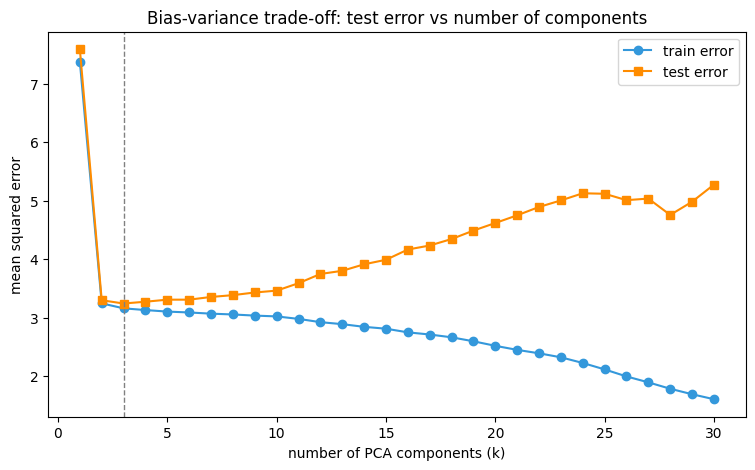

best k on test (averaged over 25 splits): 3
k=1                    (underfitting) -> test error 7.588
k=3  (true latent rank)              -> test error 3.241
k=30 (overfitting)                    -> test error 5.273


In [20]:
# Demo: train/test error vs the number of PCA components (read-only)
# Bias/variance are expectations over random data, so we average 25 train/test splits.
n_seeds = 25
train_errs = np.zeros(p_r)
test_errs = np.zeros(p_r)
for s in range(n_seeds):
    Xtr, Xte, ytr, yte = train_test_split(X_reg, y_reg, test_size=0.3,
                                          random_state=1000 + s)
    for k in range(1, p_r + 1):
        pca_k = PCA(n_components=k).fit(Xtr)
        Ztr, Zte = pca_k.transform(Xtr), pca_k.transform(Xte)
        reg_k = LinearRegression().fit(Ztr, ytr)
        train_errs[k - 1] += np.mean((reg_k.predict(Ztr) - ytr) ** 2)
        test_errs[k - 1] += np.mean((reg_k.predict(Zte) - yte) ** 2)
train_errs /= n_seeds
test_errs /= n_seeds

ks = list(range(1, p_r + 1))
best_k = int(np.argmin(test_errs)) + 1
plt.figure(figsize=(9, 5))
plt.plot(ks, train_errs, "o-", color="#3498db", label="train error")
plt.plot(ks, test_errs, "s-", color="darkorange", label="test error")
plt.axvline(best_k, color="gray", ls="--", lw=1)
plt.xlabel("number of PCA components (k)")
plt.ylabel("mean squared error")
plt.title("Bias-variance trade-off: test error vs number of components")
plt.legend()
plt.show()
print("best k on test (averaged over %d splits): %d" % (n_seeds, best_k))
print("k=1                    (underfitting) -> test error %.3f" % test_errs[0])
print("k=3  (true latent rank)              -> test error %.3f" % test_errs[2])
print("k=%d (overfitting)                    -> test error %.3f" % (p_r, test_errs[-1]))


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;"><li style="text-align: right;">منحنی خطای آموزش با افزایش <code dir="ltr">k</code> چه رفتاری دارد؟ چرا؟ (رابطه‌اش با بایاس چیست؟)</li><li style="text-align: right;">منحنی خطای تست چه شکلی است؟ در کدام <code dir="ltr">k</code> کم‌برازش و در کدام بیش‌برازش رخ می‌دهد؟</li><li style="text-align: right;">چرا <code dir="ltr">k</code> خیلی بزرگ بهتر از <code dir="ltr">k</code> درست نیست، حتی اگر خطای آموزش را کم کند؟</li><li style="text-align: right;">آیا با حذف مؤلفه‌های کم‌اهمیت، می‌توان «نویز» را هم کم کرد؟ این کار چه ارتباطی با منظم‌سازی (Regularization) دارد؟</li></ul>
<h3 style="text-align: right;">پاسخ پیشنهادی</h3>
<p style="text-align: right;">خطای آموزش با افزایش <code dir="ltr">k</code> همیشه کم می‌شود، چون مدل انعطاف‌پذیرتر می‌شود و می‌تواند حتی نویزهای تصادفی داده‌ی آموزش را هم «حفظ» کند؛ این کاهشِ خطای آموزش به‌تنهایی نشانه‌ی خوب بودن مدل نیست.</p>
<p style="text-align: right;">خطای تست U شکل است: در <code dir="ltr">k = 1</code> کم‌برازش داریم (بایاس بالا، خطای تست حدود 7.6)، بهترین نقطه حدود <code dir="ltr">k = 3</code> است (همان رتبه‌ی نهفته‌ی واقعی، خطای حدود 3.2) و بعد از آن با افزودن مؤلفه‌های نویزی، بیش‌برازش رخ می‌دهد و خطای تست تا حدود 5.3 بالا می‌رود.</p>
<p style="text-align: right;">بنابراین <code dir="ltr">k</code> خیلی بزرگ فقط خطای آموزش را کم می‌کند؛ مدل به‌جای یادگرفتن ساختار واقعی، نویز را حفظ می‌کند و این روی داده‌ی دیده‌نشده جواب نمی‌دهد.</p>
<p style="text-align: right;">بله. حذف مؤلفه‌های کم‌اهمیت، نویز همراه آن‌ها را هم حذف می‌کند. این دقیقا همان ایده‌ی منظم‌سازی (Regularization) است: محدودکردن پیچیدگی مدل تا تعادلی بین بایاس و واریانس پیدا شود و خطای واقعی (تست) کمینه شود.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">جمع‌بندی</h2>
<p style="text-align: right;">در این تمرین دیدیم که:</p>
<ul style="text-align: right;"><li style="text-align: right;">کاهش بُعد یعنی پروجکشن داده روی چند جهت منتخب، و با یک ضرب ماتریسی <code dir="ltr">X @ W</code> انجام می‌شود.</li><li style="text-align: right;">جهت تصادفی انتخاب خوبی نیست؛ PCA جهت‌هایی را برمی‌گزیند که واریانس پروجکشن را بیشینه می‌کنند (با قیدِ واحد بودن اندازه‌ی جهت‌ها).</li><li style="text-align: right;">جوابِ این بهینه‌سازی، بردارهای ویژه‌ی ماتریس کوواریانس است و مقدار ویژه‌ی هر کدام، واریانس همان مؤلفه را نشان می‌دهد.</li><li style="text-align: right;">تعداد مؤلفه‌ها، پیچیدگی مدل را تعیین می‌کند: کم‌کردن آن بایاس را زیاد و بیش‌برازش را کم می‌کند و زیادکردنش برعکس.</li></ul>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">حالا سلول ارزیابی را اجرا کنید و نتیجه‌ی خودتان را با مقدار مرجع مقایسه کنید.</p>
</div>

In [21]:
# Train/test split of the 3D cloud for the evaluation (read-only)
X3_train, X3_test = train_test_split(X3, test_size=0.25, random_state=2024)
print("train shape:", X3_train.shape, "| test shape:", X3_test.shape)


train shape: (300, 3) | test shape: (100, 3)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ارزیابی — نتیجه‌ی کار خودتان را ببینید</h2>
<p style="text-align: right;">سلول زیر با <code dir="ltr">PCAManual(n_components=2)</code> که خودتان نوشته‌اید، روی داده‌ی آموزش برازش می‌کند، داده‌ی تست را به ۲ بُعد می‌برد و دوباره بازسازی می‌کند، و خطای بازسازی (MSE) روی داده‌ی تست را چاپ می‌کند.</p>
<p style="text-align: right;">مقدار مورد انتظار راه‌حل مرجع: <b dir="ltr">≈ 0.0441</b> (خطای بازسازی روی داده‌ی تست با <code dir="ltr">k = 2</code>؛ مقدار دقیق‌تر بعد از اجرای راه‌حل مرجع در سلول مرجع دیده می‌شود).</p>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">خروجی سلول مرجع زیر (که اجرا نمی‌کنید) مقدار راه‌حل طراح را نشان می‌دهد — نتیجه‌ی خودتان را با آن مقایسه کنید.</p>
</div>

In [22]:
# Evaluation cell - run it and compare with the reference value
pca_eval = PCAManual(n_components=2).fit(X3_train)
Z_eval = pca_eval.transform(X3_test)
X3_test_recon = pca_eval.inverse_transform(Z_eval)
mse_eval = float(((X3_test - X3_test_recon) ** 2).mean())
print(f"reconstruction MSE on held-out test data (k=2): {mse_eval:.6f}")
print("explained variance ratio:", np.round(pca_eval.explained_variance_ratio_, 4))


reconstruction MSE on held-out test data (k=2): 0.044131
explained variance ratio: [0.8502 0.1363]


In [ ]:
# Reference cell - do NOT run it (kept for comparison only)
# Designer: output of the reference solution after a full execution.


reconstruction MSE on held-out test data (k=2): 0.044131
explained variance ratio: [0.8502 0.1363]
